# Target EDA: Product Acquisitions

This notebook creates disk-backed acquisition labels, then analyses new-product purchases.

### Nạp runtime configuration từ Colab Secrets

In [ ]:
# Load the secure runtime configuration before bootstrap.
# Create the Colab Secret SANTENDER_BASE64_SECRET with the Base64 JSON bundle.
import os
try:
    from google.colab import userdata
    os.environ["COLAB_RUNTIME_CONFIG_B64"] = userdata.get("SANTENDER_BASE64_SECRET")
except Exception as error:
    raise RuntimeError(
        "Could not read the Colab Secret SANTENDER_BASE64_SECRET. "
        "Create it in Colab Secrets or provide the Base64 bundle interactively."
    ) from error

if not os.environ["COLAB_RUNTIME_CONFIG_B64"]:
    raise RuntimeError("Colab Secret SANTENDER_BASE64_SECRET is empty or unavailable.")
print("Runtime configuration loaded from Colab Secrets.")

Runtime configuration loaded from Colab Secrets.


#### Insight

- Cell này chuyển SANTENDER_BASE64_SECRET vào biến runtime mà bootstrap yêu cầu; secret được đọc trong Colab và không được in ra notebook.
- Giữ secret ở Colab Secrets, không commit Base64 bundle vào source hoặc output.

### Bootstrap project và môi trường dữ liệu

In [ ]:
# ============================================================
# BOOTSTRAP: local + Colab CPU
#
# Local: d?ng tr?c ti?p source v? .env trong working tree.
# Colab browser: l?y config t? Colab Secrets.
# VS Code ? Colab CPU: d?n m?t COLAB_RUNTIME_CONFIG_B64 bundle duy nh?t.
# ============================================================
from __future__ import annotations

import base64
import binascii
import json
import os
import subprocess
import sys
from getpass import getpass
from pathlib import Path

from dotenv import load_dotenv

REPO_OWNER = "lbngyn"
REPO_NAME = "Santander-Product-Recommendation"
REPO_BRANCH = "feat/setup-pipeline"
REPO_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
RUNTIME_CONFIG_KEYS = (
    "GITHUB_TOKEN",
    "GCP_SERVICE_ACCOUNT_JSON",
    "GOOGLE_CLOUD_PROJECT",
    "GCS_BUCKET",
    "GCS_RAW_PREFIX",
    "GCS_CHECKPOINT_PREFIX",
)


def is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and requirements.txt.")


def run_git(arguments: list[str], token: str) -> None:
    credentials = base64.b64encode(f"x-access-token:{token}".encode()).decode()
    command = ["git", "-c", f"http.https://github.com/.extraheader=AUTHORIZATION: basic {credentials}", *arguments]
    subprocess.run(command, check=True)


def decode_runtime_bundle(encoded_value: str) -> dict[str, str]:
    try:
        payload = base64.b64decode(encoded_value, validate=True).decode("utf-8")
        config = json.loads(payload)
    except (binascii.Error, UnicodeDecodeError, json.JSONDecodeError) as error:
        raise ValueError("COLAB_RUNTIME_CONFIG_B64 must be a Base64-encoded JSON object.") from error
    missing = [key for key in RUNTIME_CONFIG_KEYS if not config.get(key)]
    if missing:
        raise ValueError(f"Runtime config bundle is missing: {', '.join(missing)}")
    if isinstance(config["GCP_SERVICE_ACCOUNT_JSON"], dict):
        config["GCP_SERVICE_ACCOUNT_JSON"] = json.dumps(config["GCP_SERVICE_ACCOUNT_JSON"])
    return {key: str(config[key]) for key in RUNTIME_CONFIG_KEYS}


def load_colab_ui_secrets() -> dict[str, str] | None:
    """Return secrets only when this kernel runs through the Colab browser UI."""
    try:
        from google.colab import userdata
        github_token = userdata.get("GITHUB_TOKEN")
        if not github_token:
            return None
        config = {"GITHUB_TOKEN": github_token}
        for key in RUNTIME_CONFIG_KEYS[1:]:
            value = userdata.get(key)
            if not value:
                raise RuntimeError(f"Missing Colab Secret: {key}")
            config[key] = value
        return config
    except Exception:
        return None


def load_colab_runtime_config() -> dict[str, str]:
    """Use browser Secrets, env bundle, or one secure runtime prompt."""
    ui_config = load_colab_ui_secrets()
    if ui_config:
        print("Using Colab Secrets.")
        return ui_config

    encoded_value = os.getenv("COLAB_RUNTIME_CONFIG_B64")
    if not encoded_value:
        encoded_value = getpass("Paste COLAB_RUNTIME_CONFIG_B64 once (runtime-only): ")
    return decode_runtime_bundle(encoded_value)


IS_COLAB = is_colab_runtime()
ENV = "colab" if IS_COLAB else "local"
os.environ["SANTANDER_RUNTIME"] = ENV

if IS_COLAB:
    runtime_config = load_colab_runtime_config()
    os.environ.update(runtime_config)
    github_token = runtime_config["GITHUB_TOKEN"]
    PROJECT_ROOT = Path("/content") / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning source to Colab fast disk...")
        run_git(["clone", "--branch", REPO_BRANCH, REPO_URL, str(PROJECT_ROOT)], github_token)
    else:
        print("Syncing latest source to Colab fast disk...")

        subprocess.run([
            "git", "-C", str(PROJECT_ROOT), "config",
            "remote.origin.fetch", "+refs/heads/*:refs/remotes/origin/*"
        ], check=True)

        run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", "--prune"], github_token)
        run_git([
            "-C", str(PROJECT_ROOT),
            "checkout", "-B", REPO_BRANCH,
            f"origin/{REPO_BRANCH}"
        ], github_token)

    requirements_path = PROJECT_ROOT / "requirements.txt"
    if not requirements_path.is_file():
        raise FileNotFoundError(f"requirements.txt is missing from branch {REPO_BRANCH}.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)], check=True)

    # Persist raw CSV and Parquet checkpoints between Colab runtimes.
    from google.colab import drive
    drive_mount = Path("/content/drive")
    if not (drive_mount / "MyDrive").exists():
        drive.mount(str(drive_mount))
    DATA_ROOT = drive_mount / "MyDrive/projects/santander/data"
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    load_dotenv(PROJECT_ROOT / ".env")
    DATA_ROOT = Path(os.getenv("SANTANDER_DATA_ROOT", PROJECT_ROOT / "data"))

os.environ["SANTANDER_DATA_ROOT"] = str(DATA_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook ready | environment={ENV} | source={PROJECT_ROOT}")


Syncing latest source to Colab fast disk...
Notebook ready | environment=colab | source=/content/Santander-Product-Recommendation


#### Insight

- Bootstrap xác nhận runtime Colab sẵn sàng và project được chạy từ /content/Santander-Product-Recommendation.
- Cấu hình runtime được nạp từ Colab Secrets, không hiển thị giá trị secret trong output.

### Đồng bộ source Colab

In [ ]:
# COLAB SOURCE UPDATE
# 1) Tr?n local: git add/commit/push source m?i l?n REPO_BRANCH.
# 2) Tr?n Colab: ch?y cell n?y, sau ?? ch?y l?i c?c cell import/EDA c?n d?ng code m?i.

if not IS_COLAB:
    print("Local environment: source is already current; no Colab sync is needed.")
else:
    status = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "status", "--porcelain"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    if status:
        raise RuntimeError(
            "The Colab source copy has uncommitted changes. Do not overwrite it; "
            "restart the runtime or resolve those changes first."
        )

    run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")],
        check=True,
    )

    import importlib
    importlib.invalidate_caches()
    stale_modules = [name for name in sys.modules if name == "src" or name.startswith("src.")]
    for name in stale_modules:
        del sys.modules[name]
    print(f"Colab source updated from {REPO_BRANCH}; cleared {len(stale_modules)} cached src modules. Re-run the import/config cell, then the desired EDA cells.")


Colab source updated from feat/colab-local-run; cleared 0 cached src modules. Re-run the import/config cell, then the desired EDA cells.


#### Insight

- Source Colab đã đồng bộ branch feat/colab-local-run trước khi chạy EDA, nên kết quả khớp với code branch hiện tại.
- Nếu source thay đổi, chạy lại cell này rồi các cell import/config phụ thuộc để tránh module cache cũ.

### Tạo acquisition checkpoint

In [ ]:
from src.data.ingest import config_from_environment, run_default_ingests
from src.features.acquisition import build_acquisition_features

INGEST_CONFIG = config_from_environment()
run_default_ingests(config=INGEST_CONFIG)

feature_result = build_acquisition_features(
    train_path=INGEST_CONFIG.checkpoint_dir / 'train.parquet',
    test_path=INGEST_CONFIG.checkpoint_dir / 'test.parquet',
    processed_dir=INGEST_CONFIG.checkpoint_dir.parent / 'processed',
    memory_limit='2GB' if ENV == 'local' else '8GB',
    temp_directory=DATA_ROOT / 'duckdb_temp',
)
feature_result


[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/train_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/train.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.
[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/test_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/test.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.


{'train': '/content/drive/MyDrive/projects/santander/data/processed/train.parquet',
 'test': '/content/drive/MyDrive/projects/santander/data/processed/test.parquet',
 'product_columns': ['ind_ahor_fin_ult1',
  'ind_aval_fin_ult1',
  'ind_cco_fin_ult1',
  'ind_cder_fin_ult1',
  'ind_cno_fin_ult1',
  'ind_ctju_fin_ult1',
  'ind_ctma_fin_ult1',
  'ind_ctop_fin_ult1',
  'ind_ctpp_fin_ult1',
  'ind_deco_fin_ult1',
  'ind_deme_fin_ult1',
  'ind_dela_fin_ult1',
  'ind_ecue_fin_ult1',
  'ind_fond_fin_ult1',
  'ind_hip_fin_ult1',
  'ind_plan_fin_ult1',
  'ind_pres_fin_ult1',
  'ind_reca_fin_ult1',
  'ind_tjcr_fin_ult1',
  'ind_valo_fin_ult1',
  'ind_viv_fin_ult1',
  'ind_nomina_ult1',
  'ind_nom_pens_ult1',
  'ind_recibo_ult1'],
 'acquisition_columns': ['acq_ind_ahor_fin_ult1',
  'acq_ind_aval_fin_ult1',
  'acq_ind_cco_fin_ult1',
  'acq_ind_cder_fin_ult1',
  'acq_ind_cno_fin_ult1',
  'acq_ind_ctju_fin_ult1',
  'acq_ind_ctma_fin_ult1',
  'acq_ind_ctop_fin_ult1',
  'acq_ind_ctpp_fin_ult1',
  'acq

#### Insight

- Checkpoint acquisition đã tái sử dụng thành công cho cả train và test và bao phủ 24 product columns.
- Việc cache checkpoint giúp EDA lặp lại nhanh hơn; cần version/check schema khi thay đổi logic tạo label.

### Thiết lập DuckDB và danh sách product labels

In [ ]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

TRAIN_PARQUET = Path(feature_result['train'])
TEST_PARQUET = Path(feature_result['test']) if feature_result['test'] else None
DUCKDB_TEMP_DIR = DATA_ROOT / 'duckdb_temp'
DUCKDB_TEMP_DIR.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(database=':memory:')
con.execute(f"SET temp_directory = '{str(DUCKDB_TEMP_DIR).replace(chr(39), chr(39) * 2)}'")
con.execute("SET memory_limit = '2GB'" if ENV == 'local' else "SET memory_limit = '8GB'")

def q(sql: str, *params: object) -> pd.DataFrame:
    return con.execute(sql, list(params)).df()

def quote_identifier(name: str) -> str:
    return '"' + name.replace('"', '""') + '"'

ALL_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TRAIN_PARQUET))['column_name'].tolist()
PRODUCT_COLUMNS = [
    column
    for column in ALL_COLUMNS
    if column.endswith('_ult1') and not column.startswith('acq_')
]
ACQUISITION_COLUMNS = [f'acq_{column}' for column in PRODUCT_COLUMNS]
assert set(ACQUISITION_COLUMNS).issubset(ALL_COLUMNS), 'Acquisition checkpoint is incomplete.'


#### Insight

- Setup dùng DuckDB đọc Parquet trực tiếp, phù hợp với kích thước 13.6M dòng và tránh đưa toàn bộ dữ liệu vào pandas.
- Các truy vấn tiếp theo nên aggregate trong DuckDB, chỉ materialize kết quả nhỏ để vẽ/kiểm tra.

### Quy mô và schema của processed train

In [ ]:
processed_shape = q('SELECT COUNT(*) AS rows FROM read_parquet(?)', str(TRAIN_PARQUET))
processed_shape['columns'] = len(ALL_COLUMNS)
display(processed_shape)
display(q('DESCRIBE SELECT * FROM read_parquet(?)', str(TRAIN_PARQUET)))


,rows,columns
0,13647309,72


,column_name,column_type,null,key,default,extra
0,fecha_dato,TIMESTAMP_NS,YES,None,None,None
1,ncodpers,BIGINT,YES,None,None,None
2,ind_empleado,VARCHAR,YES,None,None,None
3,pais_residencia,VARCHAR,YES,None,None,None
4,sexo,VARCHAR,YES,None,None,None
...,...,...,...,...,...,...
67,acq_ind_valo_fin_ult1,TINYINT,YES,None,None,None
68,acq_ind_viv_fin_ult1,TINYINT,YES,None,None,None
69,acq_ind_nomina_ult1,TINYINT,YES,None,None,None
70,acq_ind_nom_pens_ult1,TINYINT,YES,None,None,None


#### Insight

- Processed train có **13,647,309 dòng × 72 cột**, gồm 24 product flags và 24 acquisition labels kiểu TINYINT.
- Đây là dữ liệu panel theo khách hàng-tháng; kiểm tra uniqueness của cặp customer/date, missingness và chronology là các bước tiếp theo quan trọng.

### Phân phối mua mới theo từng loại sản phẩm

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product,new_purchase_count
23,ind_recibo_ult1,153205
22,ind_nom_pens_ult1,84768
21,ind_nomina_ult1,73800
2,ind_cco_fin_ult1,69997
18,ind_tjcr_fin_ult1,69311
4,ind_cno_fin_ult1,37187
12,ind_ecue_fin_ult1,26378
11,ind_dela_fin_ult1,12707
17,ind_reca_fin_ult1,9238
6,ind_ctma_fin_ult1,7002


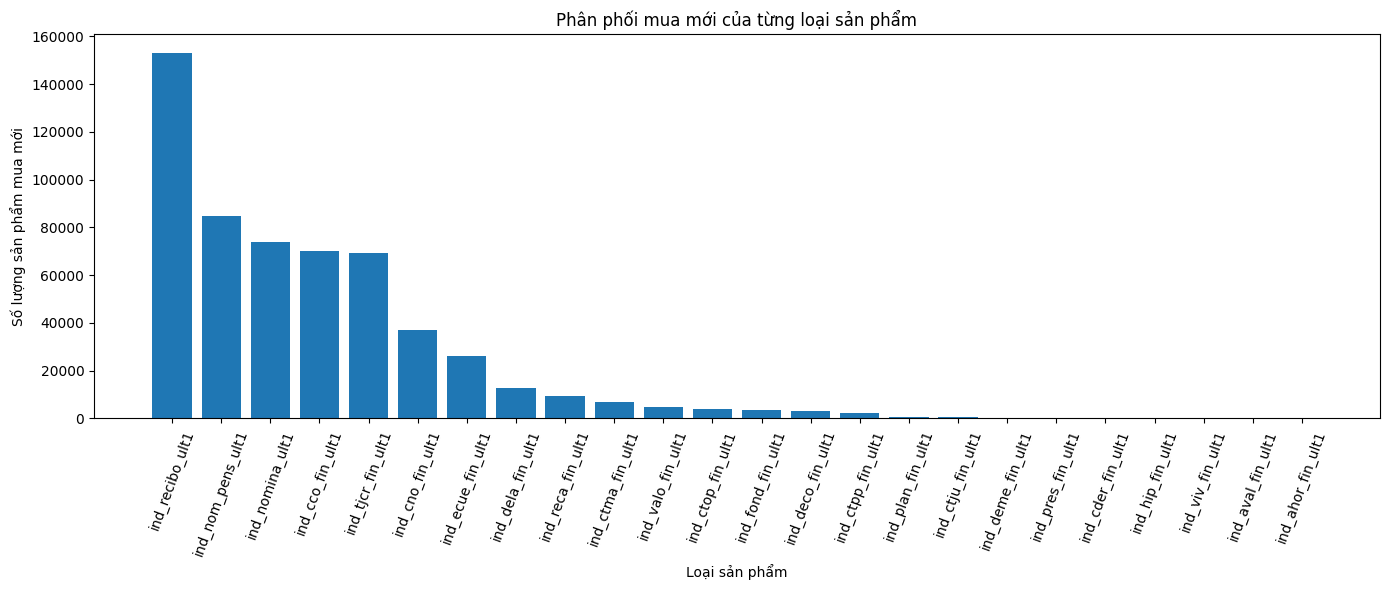

In [ ]:
# New-purchase distribution by product type.
product_acquisition_sql = ' UNION ALL '.join(
    f"SELECT '{product}' AS product, SUM({quote_identifier(acquisition)})::BIGINT AS new_purchase_count FROM read_parquet(?)"
    for product, acquisition in zip(PRODUCT_COLUMNS, ACQUISITION_COLUMNS)
)
product_acquisition = q(product_acquisition_sql, *([str(TRAIN_PARQUET)] * len(PRODUCT_COLUMNS))).sort_values('new_purchase_count', ascending=False)
display(product_acquisition)
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(product_acquisition['product'], product_acquisition['new_purchase_count'], color='#1f77b4')
ax.set(title='Phân phối mua mới của từng loại sản phẩm', xlabel='Loại sản phẩm', ylabel='Số lượng sản phẩm mua mới')
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.show()


#### Insight

- Acquisition tập trung mạnh ở ind_recibo_ult1 (153,205), tiếp theo là payroll/pension và current account/card. Các sản phẩm hiếm nhất chỉ có 2–4 lần mua.
- Với product có rất ít positive labels, mô hình riêng sẽ không đáng tin cậy. Cân nhắc prior/popularity fallback hoặc gộp theo product family.

### Tổng số sản phẩm mua mới trên mỗi khách hàng

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_new_purchases,customer_count
0,0.0,754313
1,1.0,79051
2,2.0,39848
3,3.0,27662
4,4.0,19670
5,5.0,12680
6,6.0,8637
7,7.0,5237
8,8.0,3769
9,9.0,2088


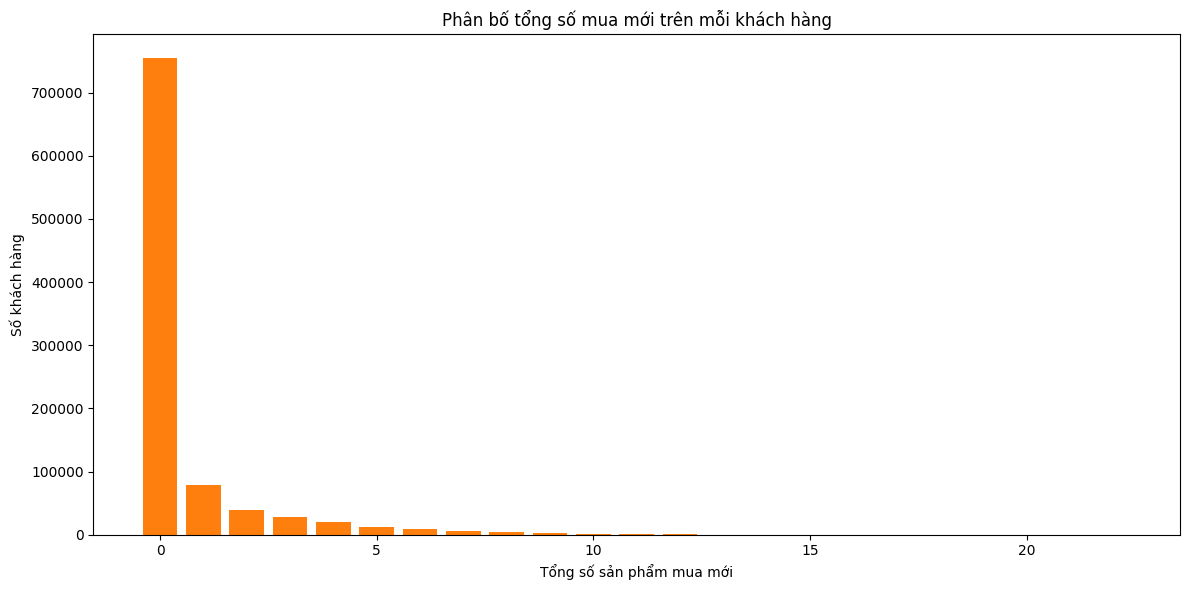

In [ ]:
# Distribution of total new purchases per customer across the full history.
total_acquisition_expression = ' + '.join(quote_identifier(column) for column in ACQUISITION_COLUMNS)
summed_acquisition_expression = ' + '.join(f'SUM({quote_identifier(column)})' for column in ACQUISITION_COLUMNS)
total_new_purchases = q(f'''
    WITH customer_totals AS (
        SELECT ncodpers, ({summed_acquisition_expression}) AS total_new_purchases
        FROM read_parquet(?)
        GROUP BY ncodpers
    )
    SELECT total_new_purchases, COUNT(*) AS customer_count
    FROM customer_totals
    GROUP BY total_new_purchases
    ORDER BY total_new_purchases
''', str(TRAIN_PARQUET))
display(total_new_purchases)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(total_new_purchases['total_new_purchases'], total_new_purchases['customer_count'], color='#ff7f0e')
ax.set(title='Phân bố tổng số mua mới trên mỗi khách hàng', xlabel='Tổng số sản phẩm mua mới', ylabel='Số khách hàng')
plt.tight_layout()
plt.show()


#### Insight

- Phân phối theo toàn lịch sử bị lệch phải: đa số khách hàng không mua thêm gì (median = 0), nhưng vẫn có khách hàng mua tối đa 22 sản phẩm.
- Cần phân tích riêng nhóm active buyer; mean toàn tập (0.5888) không đại diện cho họ.

### Số sản phẩm mua mới theo khách hàng-tháng

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,monthly_new_purchases,customer_month_count
0,0.0,13199406
1,1.0,356918
2,2.0,69048
3,3.0,19600
4,4.0,2197
5,5.0,133
6,6.0,6
7,7.0,1


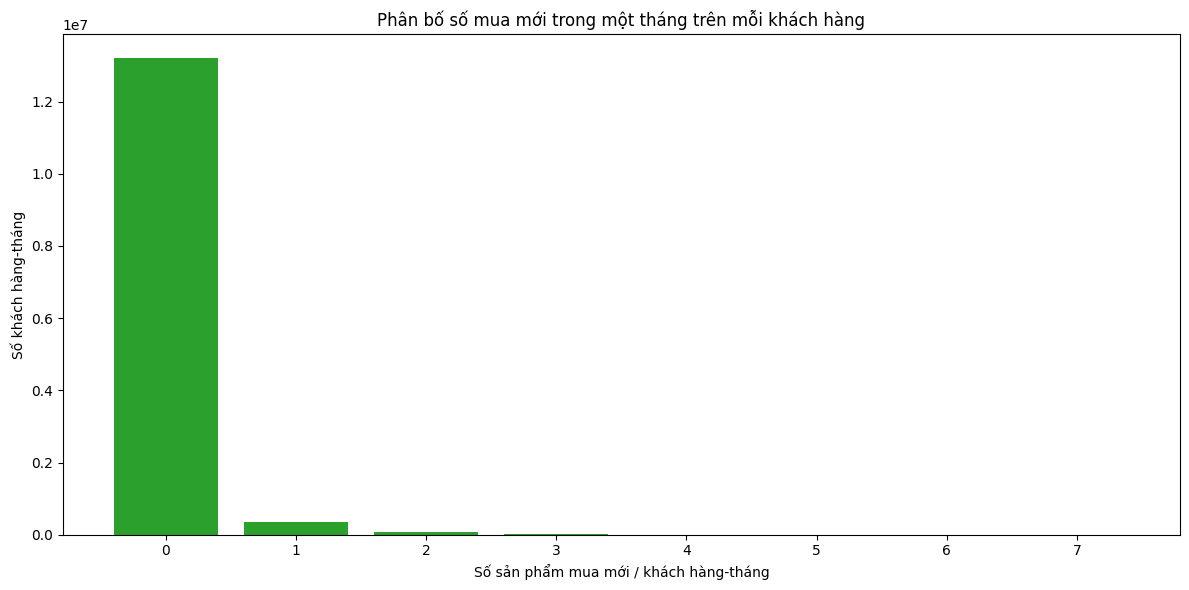

In [ ]:
# Distribution of new products purchased by a customer in one month.
monthly_new_purchases = q(f'''
    WITH customer_month_totals AS (
        SELECT ncodpers, fecha_dato, ({summed_acquisition_expression}) AS monthly_new_purchases
        FROM read_parquet(?)
        GROUP BY ncodpers, fecha_dato
    )
    SELECT monthly_new_purchases, COUNT(*) AS customer_month_count
    FROM customer_month_totals
    GROUP BY monthly_new_purchases
    ORDER BY monthly_new_purchases
''', str(TRAIN_PARQUET))
display(monthly_new_purchases)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(monthly_new_purchases['monthly_new_purchases'], monthly_new_purchases['customer_month_count'], color='#2ca02c')
ax.set(title='Phân bố số mua mới trong một tháng trên mỗi khách hàng', xlabel='Số sản phẩm mua mới / khách hàng-tháng', ylabel='Số khách hàng-tháng')
plt.tight_layout()
plt.show()


#### Insight

- Có **13,199,406 / 13,647,309 (96.72%)** customer-month không có mua mới; trong các tháng có mua, 1 sản phẩm là trường hợp chủ đạo (356,918 / 447,903).
- Bài toán tự nhiên là rank một số ít candidate products, thay vì multi-label classification không cân bằng trên toàn bộ 24 sản phẩm.

### Acquisition theo thời gian cho từng sản phẩm

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

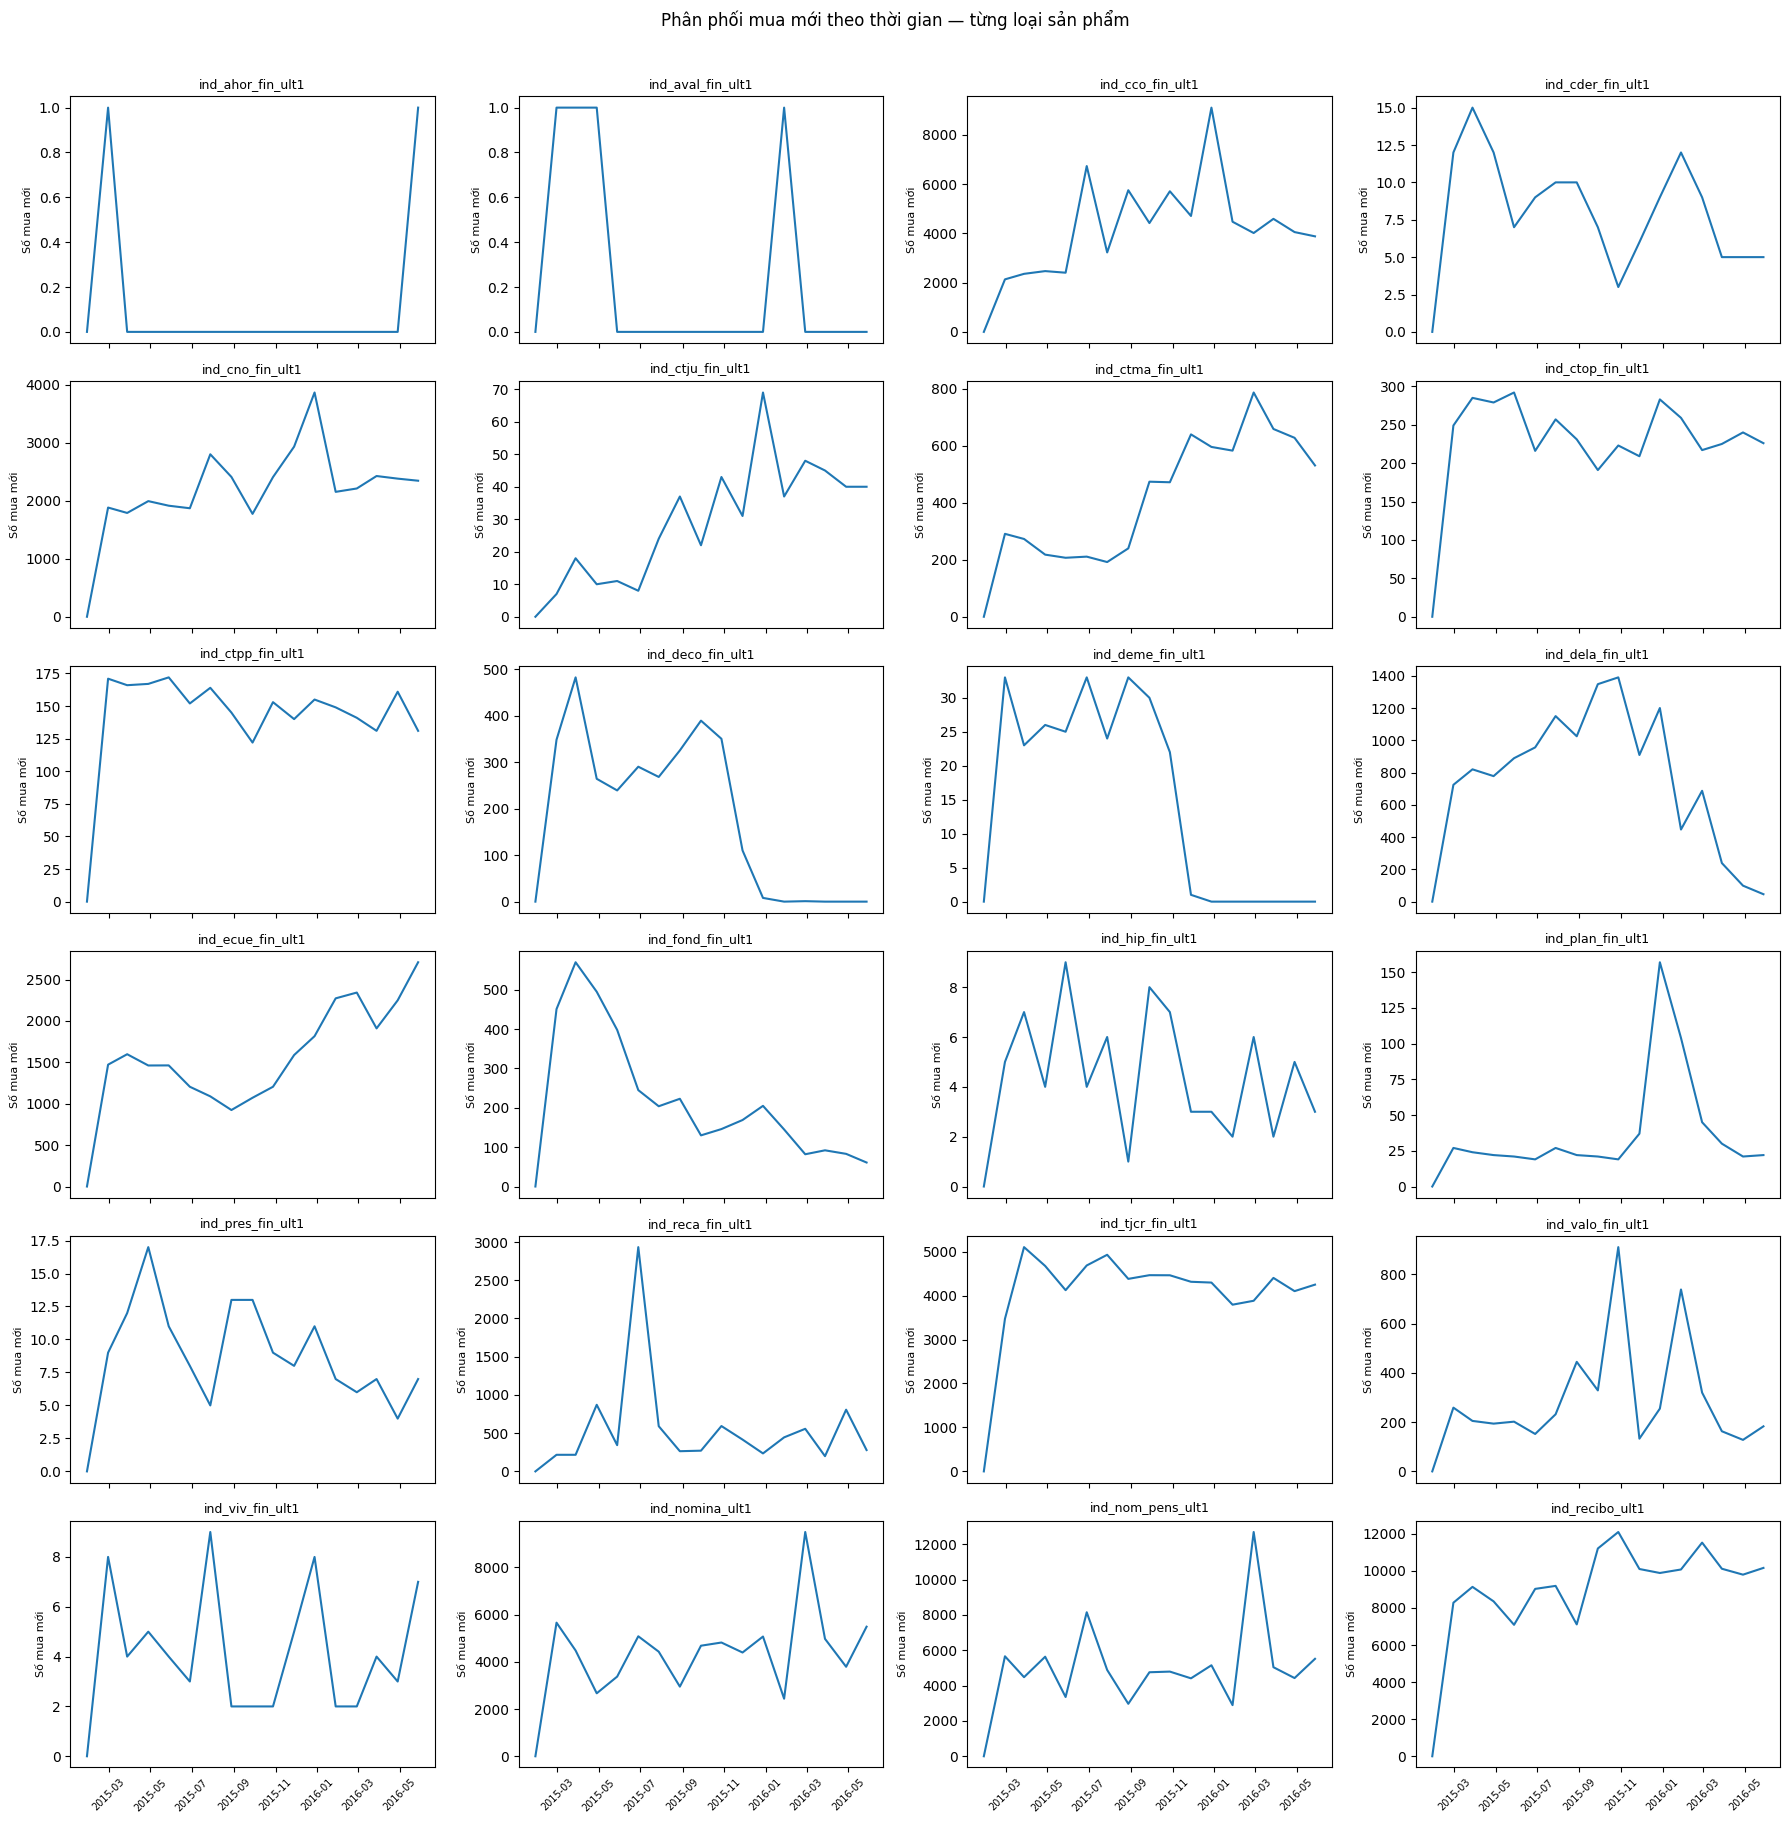

In [ ]:
# One time-series chart per product shows whether the sales peak is shared or product-specific.
monthly_product_acquisition_sql = ' UNION ALL '.join(
    f"SELECT fecha_dato, '{product}' AS product, SUM({quote_identifier(acquisition)})::BIGINT AS new_purchase_count FROM read_parquet(?) GROUP BY fecha_dato"
    for product, acquisition in zip(PRODUCT_COLUMNS, ACQUISITION_COLUMNS)
)
monthly_product_acquisition = q(
    monthly_product_acquisition_sql,
    *([str(TRAIN_PARQUET)] * len(PRODUCT_COLUMNS)),
).sort_values(['product', 'fecha_dato'])

fig, axes = plt.subplots(6, 4, figsize=(18, 18), sharex=True)
for ax, product in zip(axes.flat, PRODUCT_COLUMNS):
    data = monthly_product_acquisition[monthly_product_acquisition['product'] == product]
    ax.plot(data['fecha_dato'], data['new_purchase_count'], linewidth=1.5)
    ax.set_title(product, fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_ylabel('Số mua mới', fontsize=8)
for ax in axes.flat[len(PRODUCT_COLUMNS):]:
    ax.set_visible(False)
fig.suptitle('Phân phối mua mới theo thời gian — từng loại sản phẩm', y=1.01)
plt.tight_layout()
plt.show()


#### Insight

- Biểu đồ theo từng sản phẩm cho thấy tính mùa vụ và các đỉnh mua là **product-specific**, không nên chỉ dùng một prior chung theo thời gian.
- Nên bổ sung feature: month/year, sản phẩm khách hàng đang sở hữu, và interaction giữa thời gian với product; validation phải là split theo thời gian để tránh leakage.

### Chẩn đoán định lượng tổng quan về acquisition

In [ ]:
# Compact diagnostics for EDA interpretation.
total_stats = q(f"""
    WITH customer_totals AS (
        SELECT ncodpers, ({summed_acquisition_expression}) AS total_new_purchases
        FROM read_parquet(?)
        GROUP BY ncodpers
    )
    SELECT
        COUNT(*) AS customers,
        SUM(total_new_purchases) AS acquisitions,
        SUM(total_new_purchases > 0) AS customers_with_purchase,
        ROUND(100.0 * SUM(total_new_purchases > 0) / COUNT(*), 3) AS customer_purchase_rate,
        ROUND(AVG(total_new_purchases), 4) AS mean_purchases_per_customer,
        quantile_cont(total_new_purchases, 0.5) AS median_purchases_per_customer,
        MAX(total_new_purchases) AS max_purchases_per_customer
    FROM customer_totals
""", str(TRAIN_PARQUET))

monthly_summary = q(f"""
    SELECT
        fecha_dato,
        SUM(({total_acquisition_expression}))::BIGINT AS acquisitions,
        SUM(({total_acquisition_expression}) > 0)::BIGINT AS purchasing_customers
    FROM read_parquet(?)
    GROUP BY fecha_dato
    ORDER BY acquisitions DESC
    LIMIT 10
""", str(TRAIN_PARQUET))

display(total_stats)
display(monthly_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,customers,acquisitions,customers_with_purchase,customer_purchase_rate,mean_purchases_per_customer,median_purchases_per_customer,max_purchases_per_customer
0,956645,563310.0,202332.0,21.15,0.5888,0.0,22.0


,fecha_dato,acquisitions,purchasing_customers
0,2016-02-28,49072,36113
1,2015-12-28,42385,33713
2,2015-06-28,41991,33519
3,2015-10-28,39834,32238
4,2016-05-28,35888,27916
5,2015-09-28,35731,28510
6,2015-11-28,35266,28079
7,2016-03-28,35258,27785
8,2015-07-28,33713,26382
9,2016-04-28,33022,26791


#### Insight

- **Baseline định lượng:** 956,645 khách hàng tạo 563,310 lượt mua mới; chỉ **21.15%** từng mua ít nhất một sản phẩm và median bằng 0.
- **Đỉnh theo tháng:** tháng 2016-02 có 49,072 lượt mua mới từ 36,113 khách hàng, cao nhất trong lịch sử. Đây là target cực mất cân bằng; đánh giá mô hình nên dùng ranking/MAP@K theo tháng và có baseline “không mua”.

### <a id="stock-flow"></a>Product stock và acquisition flow theo thời gian

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product,customers_holding,acquisitions
38,ind_cco_fin_ult1,561615,3878
395,ind_recibo_ult1,113050,10163
123,ind_ctop_fin_ult1,100589,226
208,ind_ecue_fin_ult1,75845,2709
68,ind_cno_fin_ult1,73061,2347
374,ind_nom_pens_ult1,52848,5513
361,ind_nomina_ult1,48309,5488
296,ind_reca_fin_ult1,45535,279
310,ind_tjcr_fin_ult1,34822,4248
136,ind_ctpp_fin_ult1,33271,131


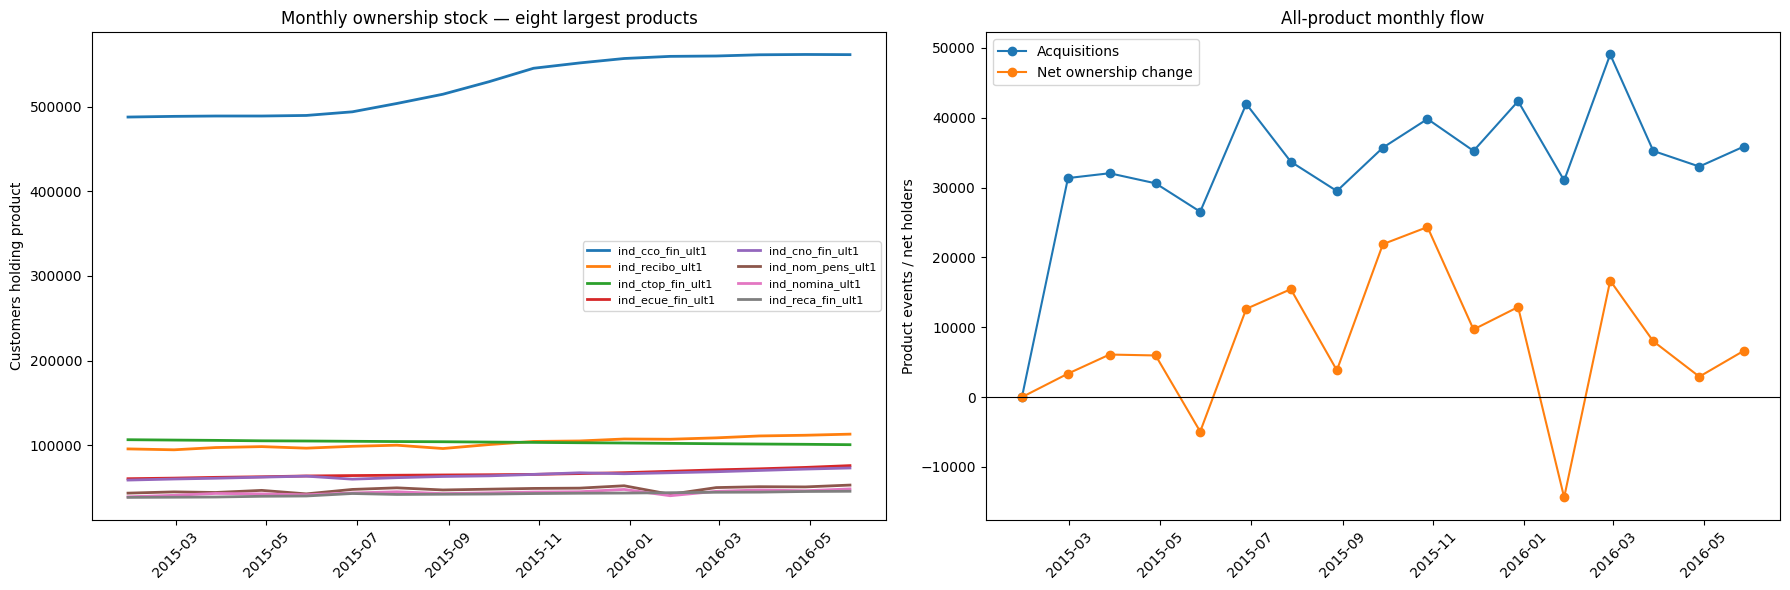

In [ ]:
ownership_sql = ' UNION ALL '.join(
    """
    SELECT fecha_dato, '{product}' AS product,
           SUM({quote_identifier(product)})::BIGINT AS customers_holding,
           SUM({quote_identifier(acquisition)})::BIGINT AS acquisitions
    FROM read_parquet(?) GROUP BY fecha_dato
    """
    for product, acquisition in zip(PRODUCT_COLUMNS, ACQUISITION_COLUMNS)
)
monthly_product_stock = q(ownership_sql, *([str(TRAIN_PARQUET)] * len(PRODUCT_COLUMNS)))
monthly_product_stock = monthly_product_stock.sort_values(['fecha_dato', 'product'])
monthly_product_stock['net_holders_change'] = monthly_product_stock.groupby('product')['customers_holding'].diff()
latest_product_stock = (monthly_product_stock.sort_values('fecha_dato').groupby('product', as_index=False).tail(1)
                        .sort_values('customers_holding', ascending=False))
display(latest_product_stock[['product', 'customers_holding', 'acquisitions']])

top_products = latest_product_stock.head(8)['product'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for product in top_products:
    data = monthly_product_stock[monthly_product_stock['product'] == product]
    axes[0].plot(data['fecha_dato'], data['customers_holding'], label=product, linewidth=2)
axes[0].set(title='Monthly ownership stock — eight largest products', ylabel='Customers holding product')
axes[0].tick_params(axis='x', rotation=45); axes[0].legend(fontsize=8, ncol=2)
monthly_flow = monthly_product_stock.groupby('fecha_dato', as_index=False).agg(acquisitions=('acquisitions', 'sum'), net_holders_change=('net_holders_change', 'sum'))
axes[1].plot(monthly_flow['fecha_dato'], monthly_flow['acquisitions'], marker='o', label='Acquisitions')
axes[1].plot(monthly_flow['fecha_dato'], monthly_flow['net_holders_change'], marker='o', label='Net ownership change')
axes[1].axhline(0, color='black', linewidth=.8); axes[1].set(title='All-product monthly flow', ylabel='Product events / net holders')
axes[1].tick_params(axis='x', rotation=45); axes[1].legend()
plt.tight_layout(); plt.show()

#### Insight — product stock vs flow

- Ownership stock is highly concentrated: latest snapshot has 561,615 holders of `ind_cco_fin_ult1`, while `ind_recibo_ult1` is the strongest current acquisition flow (10,163).
- A product's installed base and its current acquisition propensity are different signals. Model features should keep both: lagged ownership, product-specific rolling acquisition rate, and monthly net stock change.
- Preprocessing: derive these features using only months strictly before the prediction month; do not use the current month's product flag as a feature when predicting acquisition.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product,acquisitions,closures,closure_rate,retention_rate
9,ind_deco_fin_ult1,3074,6400,0.267145,0.732855
18,ind_tjcr_fin_ult1,69311,70449,0.123391,0.876609
22,ind_nom_pens_ult1,84767,76079,0.100479,0.899477
21,ind_nomina_ult1,73799,65298,0.093606,0.906350
23,ind_recibo_ult1,153205,136594,0.083692,0.916308
6,ind_ctma_fin_ult1,7002,10021,0.080400,0.919600
10,ind_deme_fin_ult1,250,849,0.039220,0.960780
11,ind_dela_fin_ult1,12707,18515,0.033351,0.966649
3,ind_cder_fin_ult1,136,127,0.025099,0.974901
1,ind_aval_fin_ult1,4,7,0.023333,0.976667


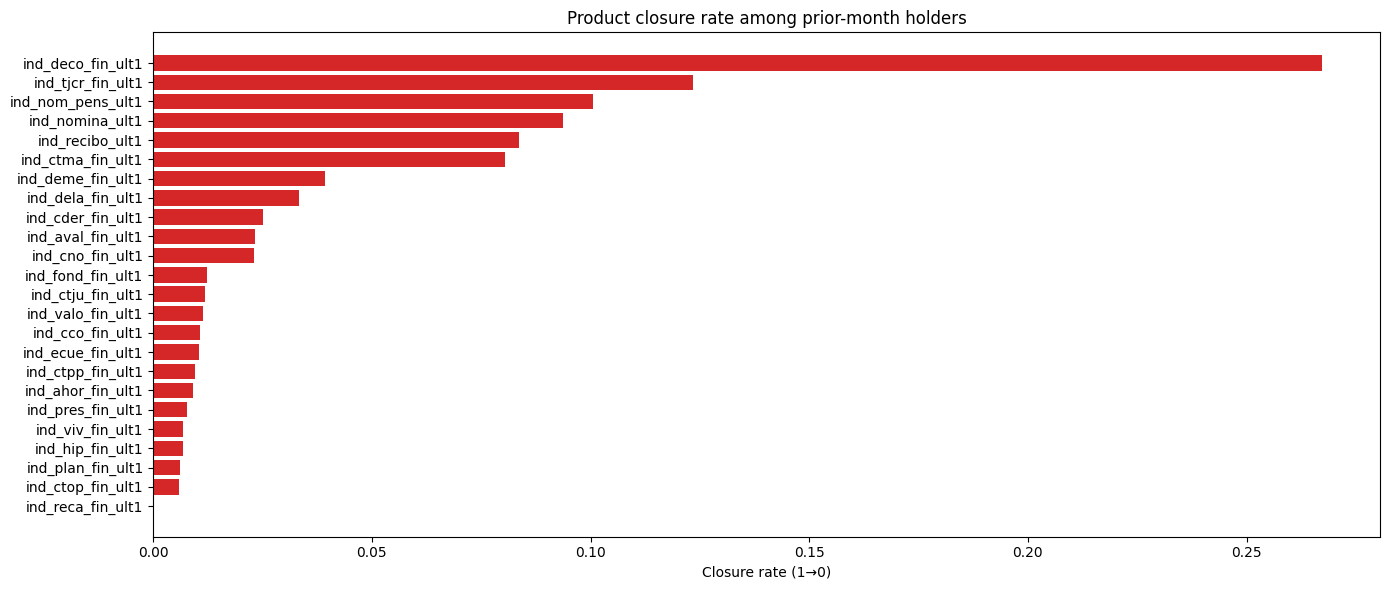

In [ ]:
transition_sql = ' UNION ALL '.join(
    f"""SELECT * FROM (
        WITH ordered AS (
            SELECT ncodpers, fecha_dato, {quote_identifier(product)} AS owned,
                   LAG({quote_identifier(product)}) OVER (PARTITION BY ncodpers ORDER BY fecha_dato) AS previous_owned
            FROM read_parquet(?)
        )
        SELECT '{product}' AS product,
               SUM(previous_owned = 0 AND owned = 1)::BIGINT AS acquisitions,
               SUM(previous_owned = 1 AND owned = 0)::BIGINT AS closures,
               SUM(previous_owned = 1 AND owned = 1)::BIGINT AS retained,
               SUM(previous_owned = 1)::BIGINT AS prior_holders
        FROM ordered
    )"""
    for product in PRODUCT_COLUMNS
)
product_transitions = q(transition_sql, *([str(TRAIN_PARQUET)] * len(PRODUCT_COLUMNS)))
product_transitions['closure_rate'] = product_transitions['closures'] / product_transitions['prior_holders']
product_transitions['retention_rate'] = product_transitions['retained'] / product_transitions['prior_holders']
product_transitions = product_transitions.sort_values('closure_rate', ascending=False)
display(product_transitions[['product', 'acquisitions', 'closures', 'closure_rate', 'retention_rate']])

fig, ax = plt.subplots(figsize=(14, 6))
plot_data = product_transitions.sort_values('closure_rate', ascending=True)
ax.barh(plot_data['product'], plot_data['closure_rate'], color='#d62728')
ax.set(title='Product closure rate among prior-month holders', xlabel='Closure rate (1→0)')
plt.tight_layout(); plt.show()

### <a id="product-transitions"></a>Tỷ lệ mở, đóng và duy trì sản phẩm theo tháng

#### Insight — chuyển trạng thái sản phẩm theo tháng

- Sản phẩm có hành vi rất khác nhau: `ind_deco_fin_ult1` có tỷ lệ đóng 26.7%, trong khi `ind_reca_fin_ult1` gần như giữ lại hoàn toàn (99.998%).
- Các sản phẩm có acquisition lớn nhưng closure cao, như thẻ tín dụng, payroll/pension và direct debit, cần được xem như tín hiệu lifecycle động thay vì portfolio ổn định.
- Feature engineering: tạo cờ mới-mở, mới-đóng, số tháng từ lần mở/đóng gần nhất và rolling count 3/6 tháng cho từng nhóm sản phẩm. Với product có rất ít event, nên dùng feature theo product family hoặc smoothing thay vì rate thô.

### <a id="portfolio-trend"></a>Diễn biến quy mô portfolio và cường độ mua mới theo thời gian

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fecha_dato,customer_months,mean_products_held,median_products_held,p90_products_held,mean_products_acquired,purchasing_customers
0,2015-01-28,625457,1.779,1.0,4.0,0.0000,0.0
1,2015-02-28,627394,1.778,1.0,4.0,0.0500,23782.0
2,2015-03-28,629209,1.783,1.0,4.0,0.0510,25305.0
3,2015-04-28,630367,1.789,1.0,4.0,0.0486,25664.0
4,2015-05-28,631957,1.777,1.0,4.0,0.0420,21422.0
5,2015-06-28,632110,1.794,1.0,4.0,0.0664,33519.0
6,2015-07-28,829817,1.383,1.0,3.0,0.0406,26382.0
7,2015-08-28,843201,1.366,1.0,3.0,0.0350,24349.0
8,2015-09-28,865440,1.356,1.0,3.0,0.0413,28510.0
9,2015-10-28,892251,1.343,1.0,3.0,0.0446,32238.0


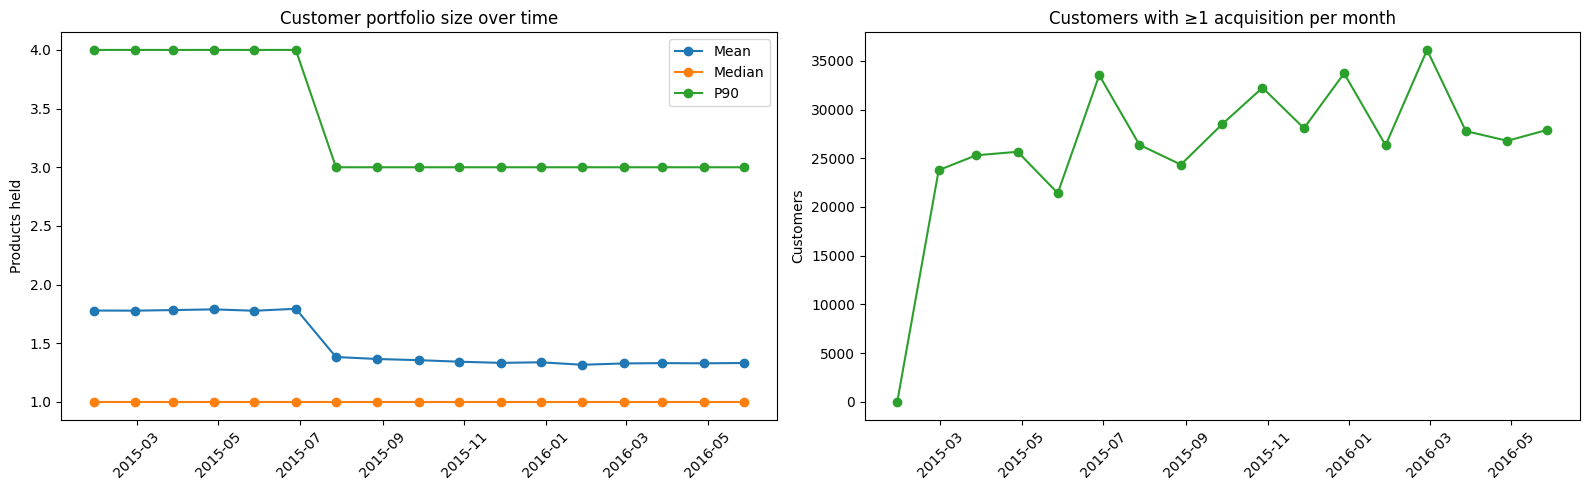

In [ ]:
portfolio_expression = ' + '.join(quote_identifier(product) for product in PRODUCT_COLUMNS)
monthly_portfolio = q(f"""
    WITH customer_month AS (
        SELECT fecha_dato, ncodpers,
               ({portfolio_expression}) AS products_held,
               ({total_acquisition_expression}) AS products_acquired
        FROM read_parquet(?)
    )
    SELECT
        fecha_dato,
        COUNT(*) AS customer_months,
        ROUND(AVG(products_held), 3) AS mean_products_held,
        quantile_cont(products_held, 0.5) AS median_products_held,
        quantile_cont(products_held, 0.9) AS p90_products_held,
        ROUND(AVG(products_acquired), 4) AS mean_products_acquired,
        SUM(products_acquired > 0) AS purchasing_customers
    FROM customer_month
    GROUP BY fecha_dato
    ORDER BY fecha_dato
""", str(TRAIN_PARQUET))
display(monthly_portfolio)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(monthly_portfolio['fecha_dato'], monthly_portfolio['mean_products_held'], marker='o', label='Mean')
axes[0].plot(monthly_portfolio['fecha_dato'], monthly_portfolio['median_products_held'], marker='o', label='Median')
axes[0].plot(monthly_portfolio['fecha_dato'], monthly_portfolio['p90_products_held'], marker='o', label='P90')
axes[0].set(title='Customer portfolio size over time', ylabel='Products held'); axes[0].tick_params(axis='x', rotation=45); axes[0].legend()
axes[1].plot(monthly_portfolio['fecha_dato'], monthly_portfolio['purchasing_customers'], marker='o', color='#2ca02c')
axes[1].set(title='Customers with ≥1 acquisition per month', ylabel='Customers'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

#### Insight — quy mô portfolio khách hàng theo thời gian

- Median luôn bằng 1 sản phẩm; P90 giảm từ 4 xuống 3 sau tháng 2015-07. Khi số customer-month tăng mạnh từ khoảng 632 nghìn lên 830 nghìn, mean products held giảm từ 1.794 xuống 1.383.
- Đây là dấu hiệu thay đổi cấu trúc/quy mô population, không nên diễn giải toàn bộ biến động acquisition là thay đổi hành vi thuần túy.
- Preprocessing: dùng feature chuẩn hoá theo tháng (monthly rate hoặc month fixed effect), theo dõi cohort khách hàng theo tháng xuất hiện đầu tiên, và áp dụng validation theo thời gian. RFM-proxy nên ghi rõ population/cohort để tránh so sánh sai giữa các giai đoạn.

### <a id="product-seasonality"></a>Mùa vụ acquisition theo sản phẩm và mức độ đồng thời mua sản phẩm

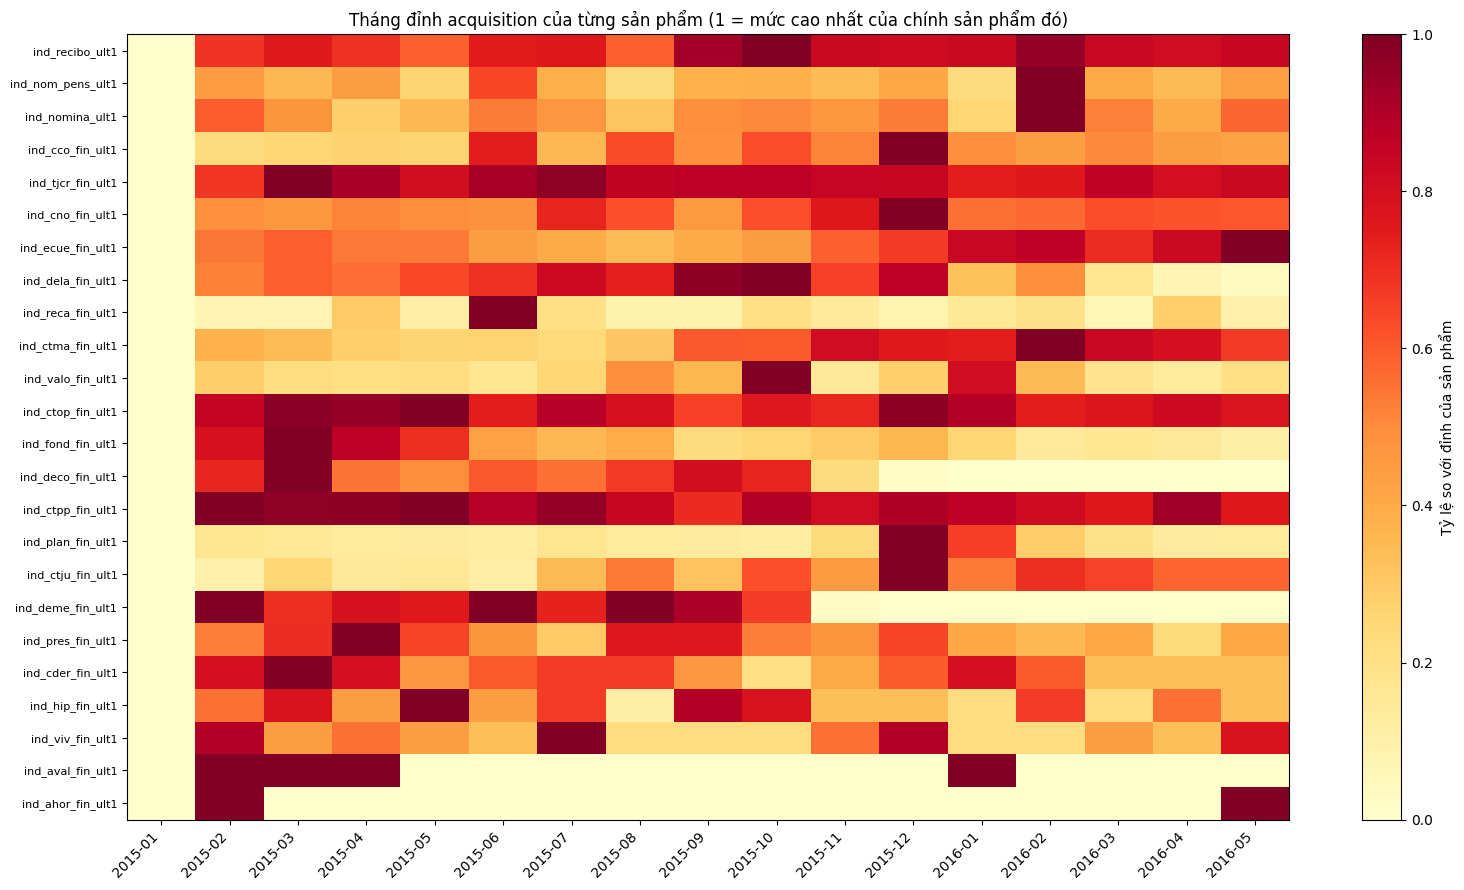

,peak_month,peak_acquisitions
product,,
ind_deme_fin_ult1,2015-02-28,33
ind_ahor_fin_ult1,2015-02-28,1
ind_aval_fin_ult1,2015-02-28,1
ind_tjcr_fin_ult1,2015-03-28,5101
ind_fond_fin_ult1,2015-03-28,570
ind_deco_fin_ult1,2015-03-28,482
ind_cder_fin_ult1,2015-03-28,15
ind_pres_fin_ult1,2015-04-28,17
ind_ctop_fin_ult1,2015-05-28,292


In [ ]:
# Heatmap chuẩn hoá theo từng sản phẩm: làm rõ tháng đỉnh acquisition.
peak_base = monthly_product_acquisition.pivot(index='product', columns='fecha_dato', values='new_purchase_count').fillna(0)
peak_order = peak_base.sum(axis=1).sort_values(ascending=False).index
peak_share = peak_base.div(peak_base.max(axis=1).replace(0, 1), axis=0).loc[peak_order]

fig, ax = plt.subplots(figsize=(16, 9))
image = ax.imshow(peak_share, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_yticks(range(len(peak_share.index))); ax.set_yticklabels(peak_share.index, fontsize=8)
ax.set_xticks(range(len(peak_share.columns))); ax.set_xticklabels([date.strftime('%Y-%m') for date in peak_share.columns], rotation=45, ha='right')
ax.set(title='Tháng đỉnh acquisition của từng sản phẩm (1 = mức cao nhất của chính sản phẩm đó)')
fig.colorbar(image, ax=ax, label='Tỷ lệ so với đỉnh của sản phẩm')
plt.tight_layout(); plt.show()

product_peak_month = (peak_base.idxmax(axis=1).rename('peak_month').to_frame()
                      .join(peak_base.max(axis=1).rename('peak_acquisitions'))
                      .sort_values(['peak_month', 'peak_acquisitions'], ascending=[True, False]))
display(product_peak_month)

#### Insight — mùa vụ theo sản phẩm và bảng tổng kết EDA

- Heatmap chuẩn hoá theo đỉnh riêng của mỗi sản phẩm làm lộ mùa mua mà biểu đồ 24 ô che khuất: thẻ tín dụng đạt đỉnh 2015-03; direct debit, loan và securities cùng đỉnh 2015-10; current account và payroll/pension cùng tăng mạnh vào 2015-12 đến 2016-02.
- Không nên dùng tổng acquisition chung làm seasonal feature duy nhất. Dùng month-of-year × product, lagged product acquisition rate và product-family seasonality; với product hiếm cần smoothing hoặc prior thay vì học peak thô.

| Insight rút ra là gì? | Biểu đồ nào thể hiện insight đó? | Xử lý dữ liệu / mô hình / feature engineering |
|---|---|---|
| Quy mô portfolio giảm khi population tăng mạnh từ 2015-07; median vẫn là 1 sản phẩm. | [Diễn biến portfolio theo thời gian](#portfolio-trend) | Chuẩn hoá theo tháng, thêm cohort/tháng xuất hiện đầu tiên và chia validation theo thời gian. |
| Một số sản phẩm là lifecycle động (đóng nhiều), một số gần như ổn định. | [Tỷ lệ mở, đóng và duy trì sản phẩm](#product-transitions) | Cờ mở/đóng gần nhất, months-since-event, rolling event count 3/6 tháng; smoothing cho product hiếm. |
| Đỉnh acquisition khác nhau theo sản phẩm; có các cụm đỉnh chung theo tháng. | [Heatmap mùa vụ acquisition](#product-seasonality) | Month × product interaction, product-family seasonal prior, lagged monthly acquisition rate. |
| Stock sản phẩm và flow acquisition không cùng phân bố. | [Product stock vs acquisition flow](#stock-flow) | Tách lagged ownership, net stock change và acquisition rate; chỉ dùng dữ liệu trước tháng dự báo để tránh leakage. |